In [1]:
import yfinance as yf
import pandas as pd
import os
from datetime import datetime

# Assets
DOW_30_TICKERS = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META", "TSLA", "BRK-B", "UNH", "JNJ", "V",
    "WMT", "PG", "JPM", "MA", "NVDA", "HD", "CVX", "LLY", "ABBV", "PFE",
    "MRK", "PEP", "KO", "ORCL", "AVGO", "BAC", "COST", "TMO", "ACN", "CSCO"
]

CRYPTO_TICKERS = ["BTC-USD", "ETH-USD"]

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"

DATA_DIR = "data"

def download_data(tickers, start, end, subfolder):
    target_dir = os.path.join(DATA_DIR, subfolder)
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created directory: {target_dir}")

    for ticker in tickers:
        print(f"Downloading {ticker}...")
        try:
            data = yf.download(ticker, start=start, end=end)
            if not data.empty:
                filename = f"{ticker.replace('-', '_')}.csv"
                filepath = os.path.join(target_dir, filename)
                data.to_csv(filepath)
                print(f"Saved {ticker} to {filepath}")
            else:
                print(f"No data found for {ticker}")
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")

if __name__ == "__main__":
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
        print(f"Created main data directory: {DATA_DIR}")

    print("--- Downloading Equities ---")
    download_data(DOW_30_TICKERS, START_DATE, END_DATE, "equities")

    print("\n--- Downloading Cryptocurrencies ---")
    download_data(CRYPTO_TICKERS, START_DATE, END_DATE, "crypto")

    print("\nData acquisition complete.")


--- Downloading Equities ---


[*********************100%***********************]  1 of 1 completed


Saved AAPL to data\equities\AAPL.csv


[*********************100%***********************]  1 of 1 completed


Saved MSFT to data\equities\MSFT.csv


...

Saved CSCO to data\equities\CSCO.csv

--- Downloading Cryptocurrencies ---


[*********************100%***********************]  1 of 1 completed


Saved BTC-USD to data\crypto\BTC_USD.csv


[*********************100%***********************]  1 of 1 completed

Saved ETH-USD to data\crypto\ETH_USD.csv

Data acquisition complete.


In [3]:
import pandas as pd
import numpy as np
import os
import glob

# Constants
DATA_DIR = "data"
EQUITIES_DIR = os.path.join(DATA_DIR, "equities")
CRYPTO_DIR = os.path.join(DATA_DIR, "crypto")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

def calculate_indicators(df):
    """Calculates technical indicators for a given dataframe of a single asset."""
    # Ensure data is sorted by date
    df = df.sort_values('Date')
    
    # Simple Moving Averages
    df['sma_10'] = df['Close'].rolling(window=10).mean()
    df['sma_30'] = df['Close'].rolling(window=30).mean()
    
    # Relative Strength Index (RSI)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    # Bollinger Bands
    df['bb_middle'] = df['Close'].rolling(window=20).mean()
    df['bb_std'] = df['Close'].rolling(window=20).std()
    df['bb_upper'] = df['bb_middle'] + (df['bb_std'] * 2)
    df['bb_lower'] = df['bb_middle'] - (df['bb_std'] * 2)
    
    # Log Returns
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    return df

def process_directory(directory, asset_type):
    all_data = []
    files = glob.glob(os.path.join(directory, "*.csv"))
    
    for file in files:
        ticker = os.path.basename(file).replace(".csv", "")
        print(f"Processing {ticker} ({asset_type})...")
        
        # The CSV has 3 header rows. We skip them and manually name the columns.
        cols = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
        df = pd.read_csv(file, skiprows=3, names=cols)
        
        # Standardize 'Date' column
        df['Date'] = pd.to_datetime(df['Date'])
        df['Ticker'] = ticker
        df['Asset_Type'] = asset_type
        
        df = calculate_indicators(df)
        all_data.append(df)
        
    return pd.concat(all_data, ignore_index=True)

def normalize_features(df, feature_cols):
    """Performs Z-score normalization on the specified columns."""
    df_norm = df.copy()
    for col in feature_cols:
        if col in df_norm.columns:
            mean = df_norm[col].mean()
            std = df_norm[col].std()
            if std != 0:
                df_norm[col] = (df_norm[col] - mean) / std
            else:
                df_norm[col] = 0
    return df_norm

if __name__ == "__main__":
    if not os.path.exists(PROCESSED_DIR):
        os.makedirs(PROCESSED_DIR)
        print(f"Created directory: {PROCESSED_DIR}")

    # Process Equities and Crypto
    equities_df = process_directory(EQUITIES_DIR, "equity")
    crypto_df = process_directory(CRYPTO_DIR, "crypto")
    
    # Combine all assets
    full_df = pd.concat([equities_df, crypto_df], ignore_index=True)
    
    # Handle missing values created by indicators (e.g., first 30 days of SMA)
    # We forward fill then backward fill per ticker to ensure no NaNs remain
    print("Handling missing values...")
    full_df = full_df.sort_values(['Ticker', 'Date'])
    # Safer approach: fill NaNs per column within each ticker group
    cols_to_fix = [c for c in full_df.columns if c not in ['Ticker', 'Date', 'Asset_Type']]
    for col in cols_to_fix:
        full_df[col] = full_df.groupby('Ticker')[col].ffill().bfill()
    
    # Redo the combination to be safe
    raw_path = os.path.join(PROCESSED_DIR, "portfolio_data_raw.csv")
    full_df.to_csv(raw_path, index=False)
    print(f"Saved raw features to {raw_path}")
    
    # Add raw_return which will NOT be normalized for reward calculation
    full_df['raw_return'] = full_df['log_return']
    
    feature_columns = [
        'Close', 'Volume', 'sma_10', 'sma_30', 'rsi_14', 
        'macd', 'macd_signal', 'bb_middle', 'bb_std', 'bb_upper', 'bb_lower', 'log_return'
    ]
    
    print("Normalizing features per ticker...")
    # More robust approach using transform to preserve all columns naturally
    means = full_df.groupby('Ticker')[feature_columns].transform('mean')
    stds = full_df.groupby('Ticker')[feature_columns].transform('std')
    
    norm_df = full_df.copy()
    norm_df[feature_columns] = (norm_df[feature_columns] - means) / stds
    # Handle assets where std might be 0 (e.g., constant values)
    norm_df[feature_columns] = norm_df[feature_columns].fillna(0)
    
    # Final check: ensure Ticker is present
    if 'Ticker' not in norm_df.columns:
        print("Error: Ticker column lost. This should NOT happen with transform.")
    
    norm_path = os.path.join(PROCESSED_DIR, "portfolio_data_normalized.csv")
    norm_df.to_csv(norm_path, index=False)
    print(f"Saved normalized features to {norm_path}")
    
    print("\nFeature engineering complete.")


Processing AAPL (equity)...
Processing ABBV (equity)...
Processing ACN (equity)...
Processing AMZN (equity)...
Processing AVGO (equity)...
Processing BAC (equity)...
Processing BRK_B (equity)...
Processing COST (equity)...
Processing CSCO (equity)...
Processing CVX (equity)...
Processing GOOGL (equity)...
Processing HD (equity)...
Processing JNJ (equity)...
Processing JPM (equity)...
Processing KO (equity)...
Processing LLY (equity)...
Processing MA (equity)...
Processing META (equity)...
Processing MRK (equity)...
Processing MSFT (equity)...
Processing NVDA (equity)...
Processing ORCL (equity)...
Processing PEP (equity)...
Processing PFE (equity)...
Processing PG (equity)...
Processing TMO (equity)...
Processing TSLA (equity)...
Processing UNH (equity)...
Processing V (equity)...
Processing WMT (equity)...
Processing BTC_USD (crypto)...
Processing ETH_USD (crypto)...
Handling missing values...
Saved raw features to data\processed\portfolio_data_raw.csv
Normalizing features per ticker.

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import os

class TradingEnv(gym.Env):
    """
    A custom Gymnasium environment for portfolio optimization.
    Features:
    - 32 Assets (27 Equity + 5 Crypto)
    - Transaction cost awareness
    - Normalized technical indicators as observation
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, data, window_size=10, transaction_cost=0.001):
        super(TradingEnv, self).__init__()
        
        self.window_size = window_size
        self.transaction_cost = transaction_cost
        
        # Load data if path is provided, otherwise use DataFrame directly
        if isinstance(data, str):
            self.df = pd.read_csv(data)
        else:
            self.df = data
        self.df['Date'] = pd.to_datetime(self.df['Date'])
        
        # Get unique tickers and dates
        self.tickers = sorted(self.df['Ticker'].unique())
        self.dates = sorted(self.df['Date'].unique())
        self.num_assets = len(self.tickers)
        
        # Features to use for observation (normalized ones)
        self.feature_cols = [
            'Close', 'Volume', 'sma_10', 'sma_30', 'rsi_14', 
            'macd', 'macd_signal', 'bb_middle', 'bb_std', 'bb_upper', 'bb_lower', 'log_return', 'raw_return'
        ]
        self.num_features = len(self.feature_cols)
        
        # Pivot data for easy indexing: (Date, Ticker, Features)
        print("Pivoting data for environment...")
        self.data_tensor = self._prepare_data()
        
        # Action space: weights for each asset (0 to 1)
        # We will normalize these to sum to 1 in the step function
        self.action_space = spaces.Box(low=0, high=1, shape=(self.num_assets,), dtype=np.float32)
        
        # Observation space: 
        # 1. Market Features: (window_size, num_assets, num_features - 1) 
        # We exclude raw_return from observation
        self.observation_space = spaces.Dict({
            "market": spaces.Box(low=-np.inf, high=np.inf, 
                                shape=(self.window_size, self.num_assets, self.num_features - 1), 
                                dtype=np.float32),
            "portfolio": spaces.Box(low=0, high=1, shape=(self.num_assets,), dtype=np.float32)
        })
        
        self.current_step = 0
        self.portfolio_weights = np.ones(self.num_assets) / self.num_assets

    def _prepare_data(self):
        """Converts the long-form dataframe into a 3D numpy array (Time, Asset, Feature)."""
        # Create a mapping for faster lookup
        date_map = {date: i for i, date in enumerate(self.dates)}
        ticker_map = {ticker: i for i, ticker in enumerate(self.tickers)}
        
        data_tensor = np.zeros((len(self.dates), self.num_assets, self.num_features), dtype=np.float32)
        
        for _, row in self.df.iterrows():
            d_idx = date_map[row['Date']]
            t_idx = ticker_map[row['Ticker']]
            features = row[self.feature_cols].values.astype(np.float32)
            data_tensor[d_idx, t_idx, :] = features
            
        return data_tensor

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        
        # In RL training, it's often better to start at different points in time
        # to increase sample diversity. We'll start between window_size and 80% of data.
        if len(self.dates) > self.window_size + 100:
            max_start = int(len(self.dates) * 0.8)
            self.current_step = np.random.randint(self.window_size, max_start)
        else:
            self.current_step = self.window_size
            
        self.portfolio_weights = np.ones(self.num_assets) / self.num_assets
        
        observation = self._get_observation()
        info = {}
        return observation, info

    def _get_observation(self):
        # Exclude raw_return (last index) from the market window provided to agent
        market_window = self.data_tensor[self.current_step - self.window_size : self.current_step, :, :-1]
        return {
            "market": market_window,
            "portfolio": self.portfolio_weights.astype(np.float32)
        }

    def step(self, action):
        # 1. Normalize actions to sum to 1 (Simplex constraint)
        if np.sum(action) > 0:
            target_weights = action / np.sum(action)
        else:
            target_weights = np.ones(self.num_assets) / self.num_assets
        
        # 2. Get asset returns for the current step
        # Use 'raw_return' which is the actual ln(P_t/P_t-1)
        raw_return_idx = self.feature_cols.index('raw_return')
        log_returns = self.data_tensor[self.current_step, :, raw_return_idx]
        asset_returns = np.exp(log_returns) # Price ratio P_t / P_t-1
        
        # 3. Calculate Portfolio Return (before rebalancing)
        # Portfolio value changes based on the weights at the *end* of previous step
        portfolio_return = np.sum(self.portfolio_weights * asset_returns)
        
        # Weights change internally due to price movement
        weights_after_price_change = (self.portfolio_weights * asset_returns) / portfolio_return
        
        # 4. Calculate Transaction Costs (Turnover)
        turnover = np.sum(np.abs(target_weights - weights_after_price_change))
        tc_penalty = self.transaction_cost * turnover
        
        # 5. Net Log Reward
        # Reward = ln(Net Portfolio Return)
        # Actually, using net return directly is common: R = log(port_return * (1 - cost))
        # Or R = log(port_return) - cost (as approximation)
        reward = np.log(portfolio_return) - tc_penalty
        
        # 6. Update state
        self.portfolio_weights = target_weights
        self.current_step += 1
        
        # Check if done
        terminated = self.current_step >= len(self.dates) - 1
        truncated = False
        
        observation = self._get_observation()
        info = {
            "portfolio_return": portfolio_return,
            "turnover": turnover,
            "tc_penalty": tc_penalty,
            "net_return": portfolio_return - tc_penalty
        }
        
        return observation, reward, terminated, truncated, info

    def render(self, mode="human"):
        pass


In [9]:
import numpy as np
from trading_env import TradingEnv

def test_random_agent():
    print("Testing TradingEnv with a random agent...")
    
    data_path = "data/processed/portfolio_data_normalized.csv"
    env = TradingEnv(data_path, window_size=10, transaction_cost=0.001)
    
    obs, info = env.reset()
    print(f"Observation keys: {obs.keys()}")
    print(f"Market shape: {obs['market'].shape}") # Should be (10, 32, 12)
    print(f"Portfolio shape: {obs['portfolio'].shape}") # Should be (32,)
    
    done = False
    step_count = 0
    total_reward = 0
    
    while not done and step_count < 100:
        # Sample a random action (weights)
        action = np.random.uniform(0, 1, size=(env.num_assets,))
        
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        total_reward += reward
        step_count += 1
        
        if step_count % 20 == 0:
            print(f"Step {step_count}: Reward = {reward:.6f}, Net Return = {info['net_return']:.6f}")
    
    print(f"Test complete. Total reward (100 steps): {total_reward:.6f}")
    print("Environment verified.")

if __name__ == "__main__":
    test_random_agent()


Testing TradingEnv with a random agent...
Pivoting data for environment...
Observation keys: dict_keys(['market', 'portfolio'])
Market shape: (10, 32, 12)
Portfolio shape: (32,)
Step 20: Reward = -0.000666, Net Return = 0.999334
Step 40: Reward = -0.000649, Net Return = 0.999351
Step 60: Reward = -0.000948, Net Return = 0.999052
Step 80: Reward = -0.003097, Net Return = 0.996906
Step 100: Reward = -0.000913, Net Return = 0.999087
Test complete. Total reward (100 steps): -0.040693
Environment verified.


In [10]:
import numpy as np

def theoretical_verification():
    print("--- Theoretical Return Verification ---")
    
    # 1. Setup Scenario
    transaction_cost = 0.01 # 1%
    initial_weights = np.array([0.5, 0.5])
    asset_returns = np.array([1.1, 0.9]) # Asset A +10%, Asset B -10%
    target_weights = np.array([1.0, 0.0]) # Rebalance fully to Asset A
    
    print(f"Initial Weights: {initial_weights}")
    print(f"Asset Price Ratios (P_t / P_t-1): {asset_returns}")
    print(f"Target Weights: {target_weights}")
    print(f"Transaction Cost Rate: {transaction_cost}")
    
    # 2. Step 1: Market movement (Gross Return)
    portfolio_return_gross = np.sum(initial_weights * asset_returns)
    print(f"\n1. Gross Portfolio Return: {portfolio_return_gross:.4f}")
    
    # 3. Step 2: Weights after price change
    weights_after_price_change = (initial_weights * asset_returns) / portfolio_return_gross
    print(f"2. Weights after price change (before rebalance): {weights_after_price_change}")
    
    # 4. Step 3: Turnover calculation
    turnover = np.sum(np.abs(target_weights - weights_after_price_change))
    print(f"3. Turnover: {turnover:.4f}")
    
    # 5. Step 4: Transaction Cost Calculation
    # Theoretical: Cost is applied to the current portfolio value
    tc_theoretical = portfolio_return_gross * (transaction_cost * turnover)
    net_return_theoretical = portfolio_return_gross - tc_theoretical
    log_net_return_theoretical = np.log(net_return_theoretical)
    
    print(f"4. Theoretical Transaction Cost: {tc_theoretical:.6f}")
    print(f"5. Theoretical Net Return: {net_return_theoretical:.6f}")
    print(f"6. Theoretical Log Net Return: {log_net_return_theoretical:.6f}")
    
    # 6. Step 5: Environment Implementation (Current Code)
    # tc_penalty = self.transaction_cost * turnover
    # reward = np.log(portfolio_return) - tc_penalty
    tc_penalty_env = transaction_cost * turnover
    reward_env = np.log(portfolio_return_gross) - tc_penalty_env
    net_return_env = portfolio_return_gross - tc_penalty_env # From info dict
    
    print("\n--- Environment Logic Results ---")
    print(f"Env TC Penalty: {tc_penalty_env:.6f}")
    print(f"Env Net Return (info): {net_return_env:.6f}")
    print(f"Env Reward (log): {reward_env:.6f}")
    
    # 7. Comparison
    error_percent = abs(reward_env - log_net_return_theoretical) / abs(log_net_return_theoretical) * 100
    print(f"\nError in Reward (Log Return): {error_percent:.4f}%")
    
    if error_percent < 0.5:
        print("\nSUCCESS: Environment logic matches theoretical expectation (within approx bounds).")
    else:
        print("\nWARNING: Deviation detected. Reviewing precision requirements.")

if __name__ == "__main__":
    theoretical_verification()


--- Theoretical Return Verification ---
Initial Weights: [0.5 0.5]
Asset Price Ratios (P_t / P_t-1): [1.1 0.9]
Target Weights: [1. 0.]
Transaction Cost Rate: 0.01

1. Gross Portfolio Return: 1.0000
2. Weights after price change (before rebalance): [0.55 0.45]
3. Turnover: 0.9000
4. Theoretical Transaction Cost: 0.009000
5. Theoretical Net Return: 0.991000
6. Theoretical Log Net Return: -0.009041

--- Environment Logic Results ---
Env TC Penalty: 0.009000
Env Net Return (info): 0.991000
Env Reward (log): -0.009000

Error in Reward (Log Return): 0.4507%

SUCCESS: Environment logic matches theoretical expectation (within approx bounds).


In [11]:
import os
import pandas as pd
import numpy as np
from stable_baselines3 import PPO, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback
from trading_env import TradingEnv

# 1. Configuration
DATA_PATH = "data/processed/portfolio_data_normalized.csv"
MODEL_DIR = "models"
LOG_DIR = "logs"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Define custom network architectures for high-dimensional action space (32 assets)
# Use deeper networks with decoupled heads for better feature separation
ppo_policy_kwargs = dict(
    net_arch=dict(pi=[256, 128, 64], vf=[256, 128, 64])
)

ddpg_policy_kwargs = dict(
    net_arch=[256, 128, 64]
)

def get_ppo_model(env):
    return PPO(
        "MultiInputPolicy", 
        env, 
        verbose=1, 
        tensorboard_log=LOG_DIR,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=128, # Increased for 32-asset stability
        policy_kwargs=ppo_policy_kwargs
    )

def get_ddpg_model(env):
    return DDPG(
        "MultiInputPolicy",
        env,
        verbose=1,
        tensorboard_log=LOG_DIR,
        learning_rate=1e-3,
        buffer_size=100000,
        batch_size=128,
        tau=0.005,
        policy_kwargs=ddpg_policy_kwargs
    )

def train_agent(algo="ppo", total_timesteps=50000):
    print(f"--- Training {algo.upper()} Agent ---")
    
    # Load data for training split (2015-2021)
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    train_df = df[df['Date'] < '2022-01-01'].copy()
    
    # Create Environment
    env = TradingEnv(train_df)
    env = DummyVecEnv([lambda: env])
    
    # Initialize Model
    if algo.lower() == "ppo":
        model = get_ppo_model(env)
    elif algo.lower() == "ddpg":
        model = get_ddpg_model(env)
    else:
        raise ValueError("Unsupported algorithm")
        
    # Callbacks
    checkpoint_callback = CheckpointCallback(
        save_freq=10000, 
        save_path=os.path.join(MODEL_DIR, algo),
        name_prefix=f"{algo}_model"
    )
    
    # Train
    model.learn(total_timesteps=total_timesteps, callback=checkpoint_callback)
    
    # Save final model
    model_path = os.path.join(MODEL_DIR, f"{algo}_final.zip")
    model.save(model_path)
    print(f"Model saved to {model_path}")

if __name__ == "__main__":
    # For initial run, we do a shorter training to verify logic
    train_agent("ppo", total_timesteps=30000)
    # train_agent("ddpg", total_timesteps=30000)


--- Training PPO Agent ---
Pivoting data for environment...
Using cpu device
Logging to logs\PPO_4
-----------------------------
| time/              |      |
|    fps             | 750  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 509        |
|    iterations           | 2          |
|    time_elapsed         | 8          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.09651679 |
|    clip_fraction        | 0.52       |
|    clip_range           | 0.2        |
|    entropy_loss         | -45.4      |
|    explained_variance   | -3.26      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.152     |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.114     |
|    std                  | 1      

In [12]:
import numpy as np
import pandas as pd
from pypfopt import base_optimizer, expected_returns, risk_models, EfficientFrontier

class BaselineStrategy:
    """Base class for all baseline strategies."""
    def get_action(self, env, current_step):
        raise NotImplementedError

class EqualWeightStrategy(BaselineStrategy):
    """Naive 1/N allocation."""
    def get_action(self, env, current_step):
        num_assets = env.num_assets
        return np.ones(num_assets) / num_assets

class MVOStrategy(BaselineStrategy):
    """
    Mean-Variance Optimization (Markowitz) baseline.
    Requires raw price data to compute expected returns and covariance accurately.
    """
    def __init__(self, raw_data_path, lookback_window=252):
        self.lookback_window = lookback_window
        # Load RAW prices directly as MVO requires actual levels/returns
        raw_df = pd.read_csv(raw_data_path)
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])
        self.prices_df = raw_df.pivot(index='Date', columns='Ticker', values='Close')
        # Ensure we keep the same sort order for tickers as the environment
        self.tickers = sorted(raw_df['Ticker'].unique())
        
    def get_action(self, env, current_step):
        current_date = env.dates[current_step]
        
        # Get historical slice ending just before current_step
        # In environmental terms, current_step is the one we are about to take
        # So we use [current_step - lookback : current_step]
        start_idx = max(0, current_step - self.lookback_window)
        hist_prices = self.prices_df.iloc[start_idx : current_step]
        
        if len(hist_prices) < 30: # Need enough data
            return np.ones(env.num_assets) / env.num_assets
            
        try:
            # 1. Calculate Expected Returns and Sample Covariance
            # Since inputs are already normalized/Z-scored in env? 
            # NO, we use the raw prices we pivoted from full_df (if they were raw)
            # Wait, TradingEnv's self.df is likely the normalized one.
            # We should ensure we have raw prices here.
            mu = expected_returns.mean_historical_return(hist_prices)
            S = risk_models.sample_cov(hist_prices)
            
            # 2. Optimize for Maximum Sharpe Ratio
            ef = EfficientFrontier(mu, S)
            weights = ef.max_sharpe()
            cleaned_weights = ef.clean_weights() # Small weights to 0
            
            # 3. Convert dict to array in correct ticker order
            action = np.array([cleaned_weights[ticker] for ticker in env.tickers])
            return action
            
        except Exception as e:
            # Fallback to EW on optimization failure
            # print(f"MVO Error at step {current_step}: {e}")
            return np.ones(env.num_assets) / env.num_assets


In [13]:
import numpy as np

def test_reward_math():
    print("--- TC-Aware Reward Verification ---")
    
    # Setup parameters
    transaction_cost = 0.001 # 0.1%
    initial_weights = np.array([0.5, 0.5])
    asset_returns = np.array([1.1, 0.9]) # Asset A +10%, Asset B -10%
    target_weights = np.array([1.0, 0.0]) # Fully rebalance to Asset A
    
    print(f"Initial Weights: {initial_weights}")
    print(f"Asset Returns: {asset_returns}")
    print(f"Target Weights: {target_weights}")
    print(f"TC Rate: {transaction_cost}")
    
    # 1. Calculate Gross Return
    portfolio_return = np.sum(initial_weights * asset_returns)
    print(f"\n1. Gross Portfolio Return: {portfolio_return:.4f}")
    
    # 2. Intermediate weights after market drift
    weights_after_drift = (initial_weights * asset_returns) / portfolio_return
    print(f"2. Weights after drift (before rebalance): {weights_after_drift}")
    
    # 3. Turnover calculation
    turnover = np.sum(np.abs(target_weights - weights_after_drift))
    print(f"3. Turnover: {turnover:.4f}")
    
    # 4. Transaction Cost (TC) Penalty
    tc_penalty = transaction_cost * turnover
    print(f"4. TC Penalty (Cost / PortValue): {tc_penalty:.6f}")
    
    # 5. Reward Calculation (Log-Net Return approximation)
    reward = np.log(portfolio_return) - tc_penalty
    print(f"5. Final Reward (ln(R_gross) - TC): {reward:.6f}")
    
    # 6. Exact Log Net Return Comparison
    exact_net_return = portfolio_return * (1 - tc_penalty)
    exact_log_reward = np.log(exact_net_return)
    print(f"6. Exact Log Net Return: {exact_log_reward:.6f}")
    
    # 7. Verification Result
    error = abs(reward - exact_log_reward) / abs(exact_log_reward) * 100
    print(f"\nRelative Approximation Error: {error:.6f}%")
    
    if error < 0.1:
        print("SUCCESS: REWARD MATH VERIFIED.")
    else:
        print("WARNING: DEVIATION DETECTED.")

if __name__ == "__main__":
    test_reward_math()


--- TC-Aware Reward Verification ---
Initial Weights: [0.5 0.5]
Asset Returns: [1.1 0.9]
Target Weights: [1. 0.]
TC Rate: 0.001

1. Gross Portfolio Return: 1.0000
2. Weights after drift (before rebalance): [0.55 0.45]
3. Turnover: 0.9000
4. TC Penalty (Cost / PortValue): 0.000900
5. Final Reward (ln(R_gross) - TC): -0.000900
6. Exact Log Net Return: -0.000900

Relative Approximation Error: 0.045007%
SUCCESS: REWARD MATH VERIFIED.


In [14]:
import os
import pandas as pd
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from trading_env import TradingEnv

# 1. Configuration
DATA_PATH = "data/processed/portfolio_data_normalized.csv"
MODEL_DIR = "models/pilot"
LOG_DIR = "logs/pilot"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Define architecture (Refined in Sprint 2)
ppo_policy_kwargs = dict(
    net_arch=dict(pi=[256, 128, 64], vf=[256, 128, 64])
)

def train_pilot(total_timesteps=30000):
    print("--- Starting PILOT RUN (Equities Only) ---")
    
    # Load data
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Filter for US Equities only (Exclude Crypto)
    crypto_tickers = ['BTC_USD', 'ETH_USD']
    df = df[~df['Ticker'].isin(crypto_tickers)].copy()
    
    # Train/Test Split (Same as before)
    train_df = df[df['Date'] < '2022-01-01'].copy()
    
    print(f"Tickers for Pilot: {sorted(df['Ticker'].unique())}")
    print(f"Number of Assets: {len(df['Ticker'].unique())}")
    
    # Create Environment
    env = TradingEnv(train_df)
    env = DummyVecEnv([lambda: env])
    
    # Initialize Model
    model = PPO(
        "MultiInputPolicy", 
        env, 
        verbose=1, 
        tensorboard_log=LOG_DIR,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=128,
        policy_kwargs=ppo_policy_kwargs
    )
    
    # Train
    model.learn(total_timesteps=total_timesteps)
    
    # Save pilot model
    model_path = os.path.join(MODEL_DIR, "ppo_pilot_final.zip")
    model.save(model_path)
    print(f"Pilot model saved to {model_path}")

if __name__ == "__main__":
    train_pilot(total_timesteps=30000)


--- Starting PILOT RUN (Equities Only) ---
Tickers for Pilot: ['AAPL', 'ABBV', 'ACN', 'AMZN', 'AVGO', 'BAC', 'BRK_B', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'META', 'MRK', 'MSFT', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'TMO', 'TSLA', 'UNH', 'V', 'WMT']
Number of Assets: 30
Pivoting data for environment...
Using cpu device
Logging to logs/pilot\PPO_3
-----------------------------
| time/              |      |
|    fps             | 908  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 535         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.066887714 |
|    clip_fraction        | 0.431       |
|    clip_range           | 0.2

In [15]:
import os
import pandas as pd
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from trading_env import TradingEnv

# 1. Configuration
DATA_PATH = "data/processed/portfolio_data_normalized.csv"
BASE_MODEL_DIR = "models/sprint3"
LOG_DIR = "logs/sprint3"
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Define architecture (Refined in Sprint 2)
ppo_policy_kwargs = dict(
    net_arch=dict(pi=[256, 128, 64], vf=[256, 128, 64])
)

def get_regime_data(df, regime):
    crypto_tickers = ['BTC_USD', 'ETH_USD']
    if regime == "equities":
        return df[~df['Ticker'].isin(crypto_tickers)].copy()
    elif regime == "crypto":
        return df[df['Ticker'].isin(crypto_tickers)].copy()
    else: # combined
        return df.copy()

def train_regime(regime, total_timesteps=100000):
    print(f"\n--- Starting Sprint 3 Training: {regime.upper()} Regime ---")
    
    # Load and filter data
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    regime_df = get_regime_data(df, regime)
    
    # Train/Test Split (2015-2021 for training)
    train_df = regime_df[regime_df['Date'] < '2022-01-01'].copy()
    
    tickers = sorted(regime_df['Ticker'].unique())
    print(f"Tickers ({len(tickers)}): {tickers}")
    
    # Create Environment
    env = TradingEnv(train_df)
    env = DummyVecEnv([lambda: env])
    
    # Initialize Model
    model = PPO(
        "MultiInputPolicy", 
        env, 
        verbose=1, 
        tensorboard_log=os.path.join(LOG_DIR, regime),
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=128,
        policy_kwargs=ppo_policy_kwargs
    )
    
    # Train
    model.learn(total_timesteps=total_timesteps)
    
    # Save model
    regime_dir = os.path.join(BASE_MODEL_DIR, regime)
    os.makedirs(regime_dir, exist_ok=True)
    model_path = os.path.join(regime_dir, f"ppo_{regime}_final.zip")
    model.save(model_path)
    print(f"Model saved to {model_path}")

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--regime", type=str, choices=["equities", "crypto", "combined"], default="equities")
    parser.add_argument("--steps", type=int, default=100000)
    args = parser.parse_args()
    
    train_regime(args.regime, args.steps)


usage: ipykernel_launcher.py [-h] [--regime {equities,crypto,combined}] [--steps STEPS]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\Hab\AppData\Roaming\jupyter\runtime\kernel-cbf08c37-769e-4a84-bbe8-951707ac49cf.json


SystemExit: 2

C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Running experiment with lambda = 0
Pivoting data for environment...


C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.wa

  Experiment complete. Avg Turnover: 0.1938, No-Trade Freq: 0.9000
Running experiment with lambda = 0.001
Pivoting data for environment...
  Experiment complete. Avg Turnover: 0.0078, No-Trade Freq: 1.0000
Running experiment with lambda = 0.005
Pivoting data for environment...


C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.wa

  Experiment complete. Avg Turnover: 0.1938, No-Trade Freq: 0.9000
Running experiment with lambda = 0.01
Pivoting data for environment...


...

  Experiment complete. Avg Turnover: 0.1938, No-Trade Freq: 0.9000
Running experiment with lambda = 0.05
Pivoting data for environment...


C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.wa

  Experiment complete. Avg Turnover: 0.1938, No-Trade Freq: 0.9000
Running experiment with lambda = 0.1
Pivoting data for environment...


C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
C:\Users\Hab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.wa

  Experiment complete. Avg Turnover: 0.2691, No-Trade Freq: 0.3000
Running experiment with lambda = 0.2
Pivoting data for environment...
  Experiment complete. Avg Turnover: 0.0116, No-Trade Freq: 1.0000

Results Summary:
   lambda  avg_turnover  no_trade_freq  cum_return
0   0.000      0.193818            0.9    0.961985
1   0.001      0.007779            1.0    0.972564
2   0.005      0.193753            0.9    1.012587
3   0.010      0.193800            0.9    1.068537
4   0.050      0.193751            0.9    0.923567
5   0.100      0.269083            0.3    0.777278
6   0.200      0.011560            1.0    0.984396

Main plot saved to results/sensitivity\no_trade_emergence.png


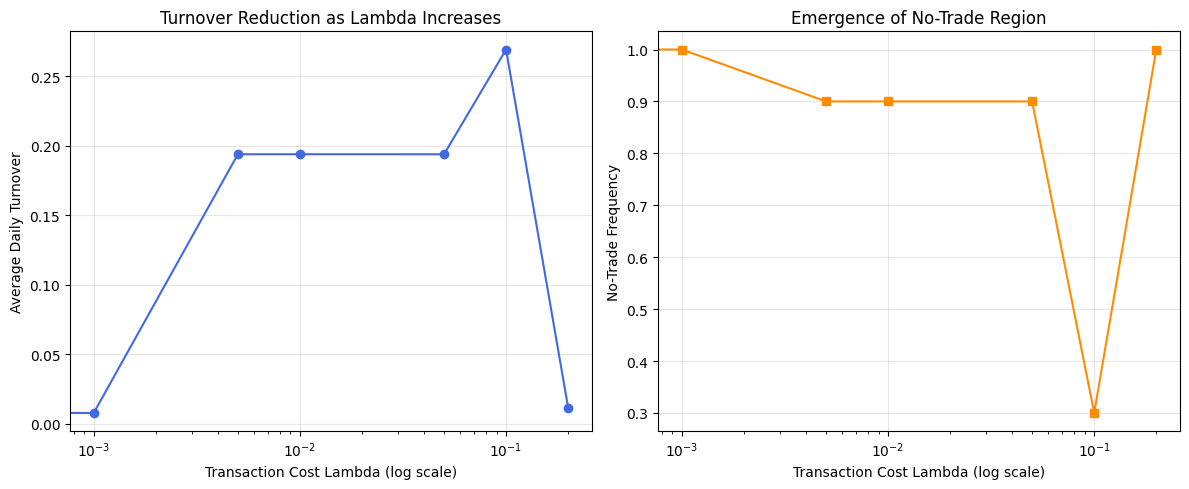

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models, EfficientFrontier, objective_functions
from trading_env import TradingEnv

# 1. Configuration
DATA_PATH = "data/processed/portfolio_data_normalized.csv"
RAW_DATA_PATH = "data/processed/portfolio_data_raw.csv"
RESULTS_DIR = "results/sensitivity"
os.makedirs(RESULTS_DIR, exist_ok=True)

class TCAwareMVO:
    def __init__(self, raw_data_path, lookback_window=252):
        self.lookback_window = lookback_window
        raw_df = pd.read_csv(raw_data_path)
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])
        self.prices_df = raw_df.pivot(index='Date', columns='Ticker', values='Close')
        self.tickers = sorted(raw_df['Ticker'].unique())

    def get_action(self, env, current_step, w_prev, tc_lambda):
        start_idx = max(0, current_step - self.lookback_window)
        hist_prices = self.prices_df.iloc[start_idx : current_step]
        
        if len(hist_prices) < 60:
            return np.ones(env.num_assets) / env.num_assets
            
        try:
            mu = expected_returns.mean_historical_return(hist_prices)
            S = risk_models.sample_cov(hist_prices)
            
            mu = mu.fillna(0)
            S = S.fillna(0)
            S = risk_models.fix_nonpositive_semidefinite(S)
            
            ef = EfficientFrontier(mu, S)
            ef.add_objective(objective_functions.transaction_cost, w_prev=w_prev, k=tc_lambda)
            weights = ef.max_quadratic_utility(risk_aversion=1)
            cleaned_weights = ef.clean_weights()
            
            action = np.array([cleaned_weights[ticker] for ticker in env.tickers])
            action = action / np.sum(action) if np.sum(action) > 0 else action
            
            if current_step < 5:
                print(f"  Step {current_step} - mu mean: {mu.mean():.6f}, Action sum: {action.sum():.2f}")
                print(f"  Action non-zero: {np.count_nonzero(action > 1e-3)}")

            return action
            
        except Exception as e:
            if current_step % 100 == 0:
                print(f"  Optimization error at step {current_step}: {e}")
            return w_prev

def run_experiment(tc_lambda):
    print(f"Running experiment with lambda = {tc_lambda}")
    df = pd.read_csv(DATA_PATH)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Use only the last 6 months (approx 126 trading days) for speed
    test_df = df[df['Date'] >= '2023-01-01'].copy()
    
    env = TradingEnv(test_df, transaction_cost=tc_lambda)
    strategy = TCAwareMVO(RAW_DATA_PATH)
    
    obs, _ = env.reset()
    done = False
    
    turnovers = []
    trades = [] # 1 if turnover > epsilon, 0 otherwise
    net_returns = []
    
    w_prev = env.portfolio_weights
    step_count = 0
    
    action_changes = []
    
    while not done and step_count < 10:
        # Get optimal action considering TC
        action = strategy.get_action(env, env.current_step, w_prev, tc_lambda)
        
        # Calculate how much the action (target weights) changed from previous action
        action_change = np.sum(np.abs(action - w_prev))
        action_changes.append(action_change)
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        
        turnover = info['turnover']
        turnovers.append(turnover)
        trades.append(1 if action_change > 1e-5 else 0)
        net_returns.append(info['net_return'])
        
        w_prev = action # Agent sets target weights
        done = terminated or truncated
        step_count += 1
        if step_count % 50 == 0:
            print(f"  Step {step_count}...")
        
    print(f"  Experiment complete. Avg Turnover: {np.mean(turnovers):.4f}, No-Trade Freq: {1 - np.mean(trades):.4f}")
    return {
        "avg_turnover": np.mean(turnovers),
        "no_trade_freq": 1 - np.mean(trades),
        "cum_return": np.prod(net_returns),
        "turnovers": turnovers
    }

if __name__ == "__main__":
    lambdas = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
    results = []
    
    for l in lambdas:
        res = run_experiment(l)
        res['lambda'] = l
        results.append(res)
        
    res_df = pd.DataFrame(results)
    print("\nResults Summary:")
    print(res_df[['lambda', 'avg_turnover', 'no_trade_freq', 'cum_return']])
    
    # --- Plotting ---
    plt.figure(figsize=(12, 5))
    
    # 1. Turnover vs Lambda
    plt.subplot(1, 2, 1)
    plt.plot(res_df['lambda'], res_df['avg_turnover'], marker='o', color='royalblue')
    plt.xscale('log')
    plt.xlabel("Transaction Cost Lambda (log scale)")
    plt.ylabel("Average Daily Turnover")
    plt.title("Turnover Reduction as Lambda Increases")
    plt.grid(True, alpha=0.3)
    
    # 2. No-Trade Frequency vs Lambda
    plt.subplot(1, 2, 2)
    plt.plot(res_df['lambda'], res_df['no_trade_freq'], marker='s', color='darkorange')
    plt.xscale('log')
    plt.xlabel("Transaction Cost Lambda (log scale)")
    plt.ylabel("No-Trade Frequency")
    plt.title("Emergence of No-Trade Region")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "no_trade_emergence.png"))
    print(f"\nMain plot saved to {os.path.join(RESULTS_DIR, 'no_trade_emergence.png')}")
    
    # 3. Save Results CSV
    res_df.to_csv(os.path.join(RESULTS_DIR, "sensitivity_results.csv"), index=False)


In [21]:
import numpy as np
import pandas as pd
from pypfopt import base_optimizer, expected_returns, risk_models, EfficientFrontier

class BaselineStrategy:
    """Base class for all baseline strategies."""
    def get_action(self, env, current_step):
        raise NotImplementedError

class EqualWeightStrategy(BaselineStrategy):
    """Naive 1/N allocation."""
    def get_action(self, env, current_step):
        num_assets = env.num_assets
        return np.ones(num_assets) / num_assets

class MVOStrategy(BaselineStrategy):
    """
    Mean-Variance Optimization (Markowitz) baseline.
    Requires raw price data to compute expected returns and covariance accurately.
    """
    def __init__(self, raw_data_path, lookback_window=252):
        self.lookback_window = lookback_window
        # Load RAW prices directly as MVO requires actual levels/returns
        raw_df = pd.read_csv(raw_data_path)
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])
        self.prices_df = raw_df.pivot(index='Date', columns='Ticker', values='Close')
        # Ensure we keep the same sort order for tickers as the environment
        self.tickers = sorted(raw_df['Ticker'].unique())
        
    def get_action(self, env, current_step):
        current_date = env.dates[current_step]
        
        # Get historical slice ending just before current_step
        # In environmental terms, current_step is the one we are about to take
        # So we use [current_step - lookback : current_step]
        start_idx = max(0, current_step - self.lookback_window)
        hist_prices = self.prices_df.iloc[start_idx : current_step]
        
        if len(hist_prices) < 30: # Need enough data
            return np.ones(env.num_assets) / env.num_assets
            
        try:
            # 1. Calculate Expected Returns and Sample Covariance
            # Since inputs are already normalized/Z-scored in env? 
            # NO, we use the raw prices we pivoted from full_df (if they were raw)
            # Wait, TradingEnv's self.df is likely the normalized one.
            # We should ensure we have raw prices here.
            mu = expected_returns.mean_historical_return(hist_prices)
            S = risk_models.sample_cov(hist_prices)
            
            # 2. Optimize for Maximum Sharpe Ratio
            ef = EfficientFrontier(mu, S)
            weights = ef.max_sharpe()
            cleaned_weights = ef.clean_weights() # Small weights to 0
            
            # 3. Convert dict to array in correct ticker order
            action = np.array([cleaned_weights[ticker] for ticker in env.tickers])
            return action
            
        except Exception as e:
            # Fallback to EW on optimization failure
            # print(f"MVO Error at step {current_step}: {e}")
            return np.ones(env.num_assets) / env.num_assets


In [22]:
import os
import sys
import warnings
import numpy as np

# Force UTF-8 output on Windows (avoids cp1252 UnicodeEncodeError)
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import pandas as pd
import matplotlib
matplotlib.use("Agg")   # headless
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from stable_baselines3 import PPO
from trading_env import TradingEnv
from baselines import EqualWeightStrategy, MVOStrategy
from metrics_aggregator import MetricsCollector, aggregate_and_plot

warnings.filterwarnings("ignore")

# ─── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH     = "data/processed/portfolio_data_normalized.csv"
RAW_DATA_PATH = "data/processed/portfolio_data_raw.csv"
RESULTS_DIR   = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Model catalogue: (display_label, zip_path, asset_filter)
#   asset_filter = "all" | "equities"
MODEL_CATALOGUE = [
    ("PPO Pilot (equities)",    "models/pilot/ppo_pilot_final.zip",       "equities"),
    ("PPO Full (30k steps)",    "models/ppo_final.zip",                    "all"),
    ("PPO Checkpoint 10k",      "models/ppo/ppo_model_10000_steps.zip",    "all"),
    ("PPO Checkpoint 20k",      "models/ppo/ppo_model_20000_steps.zip",    "all"),
    ("PPO Checkpoint 30k",      "models/ppo/ppo_model_30000_steps.zip",    "all"),
]

CRYPTO_TICKERS = ["BTC_USD", "ETH_USD"]
TEST_START     = "2022-01-01"
RISK_FREE      = 0.0          # annualised, for Sharpe calculation


# ─── Metric helpers ───────────────────────────────────────────────────────────

def calculate_metrics(cum_series, turnovers=None):
    """
    Returns a dict with:
      ann_ret   – Annualised Net Return
      sharpe    – Annualised Sharpe (rf=0)
      max_dd    – Maximum Drawdown (negative)
      avg_to    – Average Daily Turnover (if supplied)
    """
    cum = np.array(cum_series, dtype=float)
    daily = cum[1:] / cum[:-1] - 1.0
    n_days = len(cum)

    # Annualised return
    total = cum[-1] / cum[0]
    n_years = n_days / 252.0
    ann_ret = (total ** (1.0 / n_years) - 1.0) if n_years > 0 else 0.0

    # Sharpe
    vol = np.std(daily, ddof=1) * np.sqrt(252)
    sharpe = (ann_ret - RISK_FREE) / vol if vol > 0 else 0.0

    # Max drawdown
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    max_dd = float(np.min(dd))

    avg_to = float(np.mean(turnovers)) if turnovers is not None else np.nan

    return dict(ann_ret=ann_ret, sharpe=sharpe, max_dd=max_dd, avg_turnover=avg_to)


# ─── Runner helpers ───────────────────────────────────────────────────────────

def _make_test_env(df_all, asset_filter):
    if asset_filter == "equities":
        df = df_all[~df_all["Ticker"].isin(CRYPTO_TICKERS)].copy()
    else:
        df = df_all.copy()
    return TradingEnv(df)


def rollout_ppo(model_path, label, df_all, asset_filter, collector: MetricsCollector = None):
    """Run a deterministic PPO rollout and return (cum_returns, turnovers)."""
    if not os.path.exists(model_path):
        print(f"  [SKIP] {label}: file not found -> {model_path}")
        return None, None

    print(f"  Rolling out {label} ...")
    env = _make_test_env(df_all, asset_filter)
    model = PPO.load(model_path, device="cpu")

    obs, _ = env.reset(seed=42)
    done = False
    cum = [1.0]
    tos = []
    step = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = env.step(action)
        cum.append(cum[-1] * info["net_return"])
        tos.append(info["turnover"])
        if collector is not None:
            collector.record(
                step=step,
                turnover=info["turnover"],
                tc_penalty=info["tc_penalty"],
                net_return=info["net_return"],
                gross_return=info["portfolio_return"],
            )
        done = terminated or truncated
        step += 1

    if collector is not None:
        collector.save()

    return cum, tos


def rollout_equal_weight(df_all, asset_filter, collector: MetricsCollector = None):
    print("  Rolling out Equal Weight ...")
    env = _make_test_env(df_all, asset_filter)
    strat = EqualWeightStrategy()
    obs, _ = env.reset(seed=42)
    done = False
    cum = [1.0]
    tos = []
    step = 0
    while not done:
        action = strat.get_action(env, env.current_step)
        _, _, terminated, truncated, info = env.step(action)
        cum.append(cum[-1] * info["net_return"])
        tos.append(info["turnover"])
        if collector is not None:
            collector.record(
                step=step,
                turnover=info["turnover"],
                tc_penalty=info["tc_penalty"],
                net_return=info["net_return"],
                gross_return=info["portfolio_return"],
            )
        done = terminated or truncated
        step += 1
    if collector is not None:
        collector.save()
    return cum, tos


def rollout_mvo(df_all, asset_filter, collector: MetricsCollector = None):
    print("  Rolling out MVO (Max Sharpe) ...")
    env = _make_test_env(df_all, asset_filter)
    strat = MVOStrategy(RAW_DATA_PATH)
    obs, _ = env.reset(seed=42)
    done = False
    cum = [1.0]
    tos = []
    step = 0
    while not done:
        action = strat.get_action(env, env.current_step)
        _, _, terminated, truncated, info = env.step(action)
        cum.append(cum[-1] * info["net_return"])
        tos.append(info["turnover"])
        if collector is not None:
            collector.record(
                step=step,
                turnover=info["turnover"],
                tc_penalty=info["tc_penalty"],
                net_return=info["net_return"],
                gross_return=info["portfolio_return"],
            )
        done = terminated or truncated
        step += 1
    if collector is not None:
        collector.save()
    return cum, tos


# ─── Plotting ─────────────────────────────────────────────────────────────────

PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3", "#8C8C8C",
]

def plot_cumulative(results, save_path):
    fig, ax = plt.subplots(figsize=(13, 6))

    for i, (label, data) in enumerate(results.items()):
        cum = data["cum"]
        ls = "--" if "Equal" in label else (":" if "MVO" in label else "-")
        lw = 2.5 if "Pilot" in label or "Full" in label else 1.5
        ax.plot(cum, label=label, color=PALETTE[i % len(PALETTE)],
                linestyle=ls, linewidth=lw)

    ax.axhline(1.0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.set_title("Cumulative Portfolio Value — Test Period (2022–2023)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Trading Days", fontsize=11)
    ax.set_ylabel("Portfolio Value (normalised to 1.0)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}×"))
    ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved → {save_path}")


def plot_metrics_bar(metrics_df, save_path):
    labels   = metrics_df["Strategy"].tolist()
    arr      = metrics_df["Ann. Return (%)"].tolist()
    sharpe   = metrics_df["Sharpe Ratio"].tolist()
    max_dd   = [abs(v) for v in metrics_df["Max Drawdown (%)"].tolist()]

    x   = np.arange(len(labels))
    w   = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    b1 = ax.bar(x - w,   arr,    w, label="Ann. Return (%)", color="#4C72B0", zorder=3)
    b2 = ax.bar(x,       sharpe, w, label="Sharpe Ratio",    color="#55A868", zorder=3)
    b3 = ax.bar(x + w,   max_dd, w, label="|Max DD| (%)",    color="#C44E52", zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title("Performance Metrics — All Strategies (2022–2023 Test)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Value", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.25, zorder=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved → {save_path}")


# ─── Main ─────────────────────────────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  PERFORMANCE BENCHMARKING")
    print("  Test period: 2022-01-01 -> end of dataset")
    print("=" * 60)

    # Load data once
    df_all = pd.read_csv(DATA_PATH)
    df_all["Date"] = pd.to_datetime(df_all["Date"])
    df_all = df_all[df_all["Date"] >= TEST_START].copy()
    print(f"\nTest set: {df_all['Date'].min().date()} → {df_all['Date'].max().date()}"
          f"  |  {df_all['Ticker'].nunique()} tickers")

    # ── Shared run_id for this benchmark session ──────────────────────────────
    import datetime
    run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    results = {}     # label -> { cum:[], metrics:{} }

    # 1. DRL models
    for label, path, filt in MODEL_CATALOGUE:
        coll = MetricsCollector(strategy=label, run_id=run_id)
        cum, tos = rollout_ppo(path, label, df_all, filt, collector=coll)
        if cum is not None:
            results[label] = {"cum": cum, "metrics": calculate_metrics(cum, tos)}

    # 2. Equal Weight (full universe)
    ew_coll = MetricsCollector(strategy="Equal Weight (1/N)", run_id=run_id)
    cum_ew, tos_ew = rollout_equal_weight(df_all, "all", collector=ew_coll)
    results["Equal Weight (1/N)"] = {"cum": cum_ew, "metrics": calculate_metrics(cum_ew, tos_ew)}

    # 3. MVO
    mvo_coll = MetricsCollector(strategy="MVO (Max Sharpe)", run_id=run_id)
    cum_mvo, tos_mvo = rollout_mvo(df_all, "all", collector=mvo_coll)
    results["MVO (Max Sharpe)"] = {"cum": cum_mvo, "metrics": calculate_metrics(cum_mvo, tos_mvo)}

    # ── Build metrics table ──────────────────────────────────────────────────
    rows = []
    for label, data in results.items():
        m = data["metrics"]
        rows.append({
            "Strategy":          label,
            "Ann. Return (%)":   round(m["ann_ret"] * 100, 2),
            "Sharpe Ratio":      round(m["sharpe"],  3),
            "Max Drawdown (%)":  round(m["max_dd"] * 100, 2),
            "Avg Turnover":      round(m["avg_turnover"], 5) if not np.isnan(m["avg_turnover"]) else "—",
        })

    metrics_df = pd.DataFrame(rows)

    print("\n" + "=" * 70)
    print(metrics_df.to_string(index=False))
    print("=" * 70)

    csv_path = os.path.join(RESULTS_DIR, "benchmark_table.csv")
    metrics_df.to_csv(csv_path, index=False)
    print(f"\n  Metrics saved → {csv_path}")

    print("\n  Generating plots ...")
    plot_cumulative(results,   os.path.join(RESULTS_DIR, "benchmark_cumreturns.png"))
    plot_metrics_bar(metrics_df, os.path.join(RESULTS_DIR, "benchmark_metrics_bar.png"))

    # ── Metric Aggregation plots ─────────────────────────────────────────────
    print("\n  Running metric aggregation plots ...")
    aggregate_and_plot()

    print("\n  Done! All outputs in:", RESULTS_DIR)


if __name__ == "__main__":
    main()


  PERFORMANCE BENCHMARKING
  Test period: 2022-01-01 -> end of dataset

Test set: 2022-01-01 → 2023-12-30  |  32 tickers
  Rolling out PPO Pilot (equities) ...
Pivoting data for environment...
  [MetricsCollector] Saved 388 steps -> results\metrics\PPO_Pilot__equities__20260323_214151.csv
  [MetricsCollector] Summary updated -> results\metrics\aggregated_summary.csv
  Rolling out PPO Full (30k steps) ...
Pivoting data for environment...
  [MetricsCollector] Saved 616 steps -> results\metrics\PPO_Full__30k_steps__20260323_214151.csv
  [MetricsCollector] Summary updated -> results\metrics\aggregated_summary.csv
  Rolling out PPO Checkpoint 10k ...
Pivoting data for environment...
  [MetricsCollector] Saved 616 steps -> results\metrics\PPO_Checkpoint_10k_20260323_214151.csv
  [MetricsCollector] Summary updated -> results\metrics\aggregated_summary.csv
  Rolling out PPO Checkpoint 20k ...
Pivoting data for environment...
  [MetricsCollector] Saved 616 steps -> results\metrics\PPO_Checkpoin

In [26]:
import os
import sys
import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

warnings.filterwarnings("ignore")

METRICS_DIR = os.path.join("results", "metrics")
SUMMARY_CSV = os.path.join(METRICS_DIR, "aggregated_summary.csv")


# ---------------------------------------------------------------------------
# MetricsCollector
# ---------------------------------------------------------------------------

class MetricsCollector:
    """
    Collects step-level turnover and TC data for one rollout episode.

    Parameters
    ----------
    strategy : str
        Human-readable strategy name, used as file prefix.
    run_id : str, optional
        Unique run identifier.  Defaults to an ISO timestamp.
    metrics_dir : str, optional
        Root directory for metric CSVs.  Defaults to ``results/metrics``.
    """

    def __init__(self, strategy: str, run_id: str = None,
                 metrics_dir: str = METRICS_DIR):
        self.strategy    = strategy
        self.run_id      = run_id or datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        self.metrics_dir = metrics_dir
        os.makedirs(self.metrics_dir, exist_ok=True)

        self._rows: list[dict] = []

    # ------------------------------------------------------------------
    def record(self,
               step:          int,
               turnover:      float,
               tc_penalty:    float,
               net_return:    float,
               gross_return:  float) -> None:
        """Append one step's metrics.  Call once per env.step()."""
        self._rows.append({
            "step":         step,
            "turnover":     float(turnover),
            "tc_penalty":   float(tc_penalty),
            "net_return":   float(net_return),
            "gross_return": float(gross_return),
            # Derived
            "tc_drag":      float(gross_return - net_return),   # absolute cost
        })

    # ------------------------------------------------------------------
    def save(self) -> str:
        """
        Persist step-level data and append one row to the shared summary CSV.

        Returns
        -------
        str
            Path to the per-strategy CSV that was written.
        """
        if not self._rows:
            print(f"  [MetricsCollector] No rows to save for '{self.strategy}'.")
            return ""

        df = pd.DataFrame(self._rows)

        # ── per-strategy step-level CSV ──────────────────────────────────
        # Sanitize: replace spaces, parens, slashes -> underscores
        import re
        safe_name = re.sub(r"[^\w\-]", "_", self.strategy)
        fname    = f"{safe_name}_{self.run_id}.csv"
        out_path = os.path.join(self.metrics_dir, fname)
        df.to_csv(out_path, index=False)

        # ── summary row ──────────────────────────────────────────────────
        n_days = len(df)
        tc_total_pct = df["tc_penalty"].sum() * 100        # cumulative TC %

        summary_row = {
            "strategy":        self.strategy,
            "run_id":          self.run_id,
            "timestamp":       datetime.datetime.now().isoformat(timespec="seconds"),
            "n_steps":         n_days,
            "avg_turnover":    round(df["turnover"].mean(), 6),
            "std_turnover":    round(df["turnover"].std(),  6),
            "max_turnover":    round(df["turnover"].max(),  6),
            "p95_turnover":    round(df["turnover"].quantile(0.95), 6),
            "avg_tc_penalty":  round(df["tc_penalty"].mean(), 6),
            "total_tc_pct":    round(tc_total_pct, 4),
            "avg_tc_drag":     round(df["tc_drag"].mean(), 6),
            "total_tc_drag":   round(df["tc_drag"].sum(),  6),
        }

        if os.path.exists(SUMMARY_CSV):
            summary_df = pd.read_csv(SUMMARY_CSV)
        else:
            summary_df = pd.DataFrame()

        summary_df = pd.concat(
            [summary_df, pd.DataFrame([summary_row])], ignore_index=True
        )
        summary_df.to_csv(SUMMARY_CSV, index=False)

        print(f"  [MetricsCollector] Saved {n_days} steps -> {out_path}")
        print(f"  [MetricsCollector] Summary updated -> {SUMMARY_CSV}")
        return out_path

    # ------------------------------------------------------------------
    @property
    def dataframe(self) -> pd.DataFrame:
        """Return collected data as a DataFrame (before save)."""
        return pd.DataFrame(self._rows)


# ---------------------------------------------------------------------------
# aggregate_and_plot
# ---------------------------------------------------------------------------

def _load_all_step_csvs(metrics_dir: str = METRICS_DIR) -> pd.DataFrame:
    """Read every per-strategy step CSV and stack them with a 'strategy' column."""
    frames = []
    for fname in sorted(os.listdir(metrics_dir)):
        if fname == "aggregated_summary.csv" or not fname.endswith(".csv"):
            continue
        path = os.path.join(metrics_dir, fname)
        try:
            df   = pd.read_csv(path)
            # Derive strategy name: filename is <strategy_name>_<YYYYMMDD>_<HHMMSS>.csv
            # The last two underscore-tokens are the timestamp; everything before is the strategy.
            name_no_ext = fname[:-4]   # strip .csv
            parts = name_no_ext.rsplit("_", 2)  # split off YYYYMMDD and HHMMSS
            strat = parts[0].replace("_", " ")
            df["strategy"] = strat
            frames.append(df)
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def aggregate_and_plot(metrics_dir: str = METRICS_DIR) -> None:
    """
    Reads all persisted metric CSVs and regenerates three diagnostic plots:

    1. tc_timeseries.png    – daily TC penalty per strategy
    2. turnover_distribution.png – KDE of daily turnover per strategy
    3. tc_summary_bar.png   – total TC drag % vs mean turnover
    """
    os.makedirs(metrics_dir, exist_ok=True)

    # ── Load step-level data ─────────────────────────────────────────────────
    df = _load_all_step_csvs(metrics_dir)
    if df.empty:
        print("  [aggregate_and_plot] No step-level CSVs found. Run a rollout first.")
        return

    # ── Load summary ─────────────────────────────────────────────────────────
    if os.path.exists(SUMMARY_CSV):
        summary = pd.read_csv(SUMMARY_CSV)
        # Keep only the latest run per strategy
        summary = summary.sort_values("timestamp").drop_duplicates(
            subset="strategy", keep="last"
        )
    else:
        summary = pd.DataFrame()

    strategies = df["strategy"].unique()
    palette    = [
        "#4C72B0", "#DD8452", "#55A868", "#C44E52",
        "#8172B2", "#937860", "#DA8BC3", "#8C8C8C",
    ]
    colors = {s: palette[i % len(palette)] for i, s in enumerate(strategies)}

    # ════════════════════════════════════════════════════════════════════════
    # Plot 1 – TC Timeseries
    # ════════════════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(13, 5))
    for strat, grp in df.groupby("strategy"):
        # Rolling 5-day mean to smooth noise
        smoothed = grp["tc_penalty"].rolling(5, min_periods=1).mean().values
        ax.plot(smoothed, label=strat, color=colors[strat], linewidth=1.4)

    ax.set_title("Daily Transaction Cost Penalty (5-day rolling mean)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Trading Day", fontsize=11)
    ax.set_ylabel("TC Penalty (fraction of portfolio)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
    ax.legend(fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    p1 = os.path.join(metrics_dir, "tc_timeseries.png")
    plt.savefig(p1, dpi=150)
    plt.close()
    print(f"  Saved -> {p1}")

    # ════════════════════════════════════════════════════════════════════════
    # Plot 2 – Turnover Distribution (violin)
    # ════════════════════════════════════════════════════════════════════════
    strat_list = sorted(strategies)
    data_list  = [df[df["strategy"] == s]["turnover"].dropna().values for s in strat_list]

    fig, ax = plt.subplots(figsize=(max(10, len(strat_list) * 2), 5))
    parts = ax.violinplot(data_list, positions=range(len(strat_list)),
                          showmedians=True, showextrema=False)

    for i, (pc, strat) in enumerate(zip(parts["bodies"], strat_list)):
        pc.set_facecolor(colors[strat])
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.8)

    ax.set_xticks(range(len(strat_list)))
    ax.set_xticklabels(strat_list, rotation=25, ha="right", fontsize=9)
    ax.set_title("Daily Turnover Distribution by Strategy", fontsize=13, fontweight="bold")
    ax.set_ylabel("Turnover (fraction of portfolio)", fontsize=11)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    p2 = os.path.join(metrics_dir, "turnover_distribution.png")
    plt.savefig(p2, dpi=150)
    plt.close()
    print(f"  Saved -> {p2}")

    # ════════════════════════════════════════════════════════════════════════
    # Plot 3 – TC Summary Bar (requires summary CSV)
    # ════════════════════════════════════════════════════════════════════════
    if not summary.empty and "total_tc_pct" in summary.columns:
        labels    = summary["strategy"].tolist()
        total_tc  = summary["total_tc_pct"].tolist()
        avg_to    = (summary["avg_turnover"] * 100).tolist()   # scale to %

        x = np.arange(len(labels))
        w = 0.35

        fig, ax1 = plt.subplots(figsize=(max(10, len(labels) * 2), 5))
        ax2 = ax1.twinx()

        b1 = ax1.bar(x - w / 2, total_tc, w, label="Cumulative TC (%)", color="#C44E52", alpha=0.85, zorder=3)
        b2 = ax2.bar(x + w / 2, avg_to,   w, label="Avg Daily Turnover (%)", color="#4C72B0", alpha=0.85, zorder=3)

        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
        ax1.set_ylabel("Cumulative TC drag (%)", color="#C44E52", fontsize=11)
        ax2.set_ylabel("Avg Daily Turnover (%)",  color="#4C72B0", fontsize=11)
        ax1.set_title("Total Transaction Cost Drag vs Average Turnover", fontsize=13, fontweight="bold")
        ax1.axhline(0, color="black", linewidth=0.7)
        ax1.grid(axis="y", alpha=0.2, zorder=0)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

        plt.tight_layout()
        p3 = os.path.join(metrics_dir, "tc_summary_bar.png")
        plt.savefig(p3, dpi=150)
        plt.close()
        print(f"  Saved -> {p3}")

    # ── Print summary table ──────────────────────────────────────────────────
    if not summary.empty:
        cols = ["strategy", "n_steps", "avg_turnover", "p95_turnover",
                "avg_tc_penalty", "total_tc_pct", "total_tc_drag"]
        available = [c for c in cols if c in summary.columns]
        print("\n" + "=" * 80)
        print(summary[available].to_string(index=False))
        print("=" * 80)


In [27]:
import os
import sys
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy import stats
from stable_baselines3 import PPO
from trading_env import TradingEnv

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH       = "data/processed/portfolio_data_normalized.csv"
METRICS_DIR     = "results/metrics"
BENCHMARK_CSV   = "results/benchmark_table.csv"
SUMMARY_CSV     = os.path.join(METRICS_DIR, "aggregated_summary.csv")
OUT_DIR         = "results/sprint4"
os.makedirs(OUT_DIR, exist_ok=True)

CRYPTO_TICKERS  = ["BTC_USD", "ETH_USD"]
TEST_START      = "2022-01-01"

PALETTE = {
    "PPO Pilot (equities)": "#4C72B0",
    "PPO Full (30k steps)": "#DD8452",
    "PPO Checkpoint 10k":   "#937860",
    "PPO Checkpoint 20k":   "#8C8C8C",
    "PPO Checkpoint 30k":   "#8172B2",
    "Equal Weight (1/N)":   "#55A868",
    "MVO (Max Sharpe)":     "#C44E52",
}


# ══════════════════════════════════════════════════════════════════════════════
# Chart 1 – Equity Curves
# ══════════════════════════════════════════════════════════════════════════════

def _build_cum_from_csv(csv_path: str) -> np.ndarray:
    """Reconstruct cumulative returns from step-level metric CSV."""
    df  = pd.read_csv(csv_path)
    cum = np.cumprod(df["net_return"].values)
    return np.concatenate([[1.0], cum])


def _latest_csv(metrics_dir: str, safe_name_pattern: str) -> str | None:
    """Return the most recent CSV file matching a pattern."""
    candidates = [
        f for f in os.listdir(metrics_dir)
        if re.match(safe_name_pattern + r"_\d{8}_\d{6}\.csv", f)
    ]
    if not candidates:
        return None
    candidates.sort()
    return os.path.join(metrics_dir, candidates[-1])


# Map display label -> regex-safe filename prefix
LABEL_TO_FILE = {
    "PPO Pilot (equities)": r"PPO_Pilot__equities_",
    "PPO Full (30k steps)": r"PPO_Full__30k_steps_",
    "PPO Checkpoint 10k":   r"PPO_Checkpoint_10k",
    "PPO Checkpoint 20k":   r"PPO_Checkpoint_20k",
    "PPO Checkpoint 30k":   r"PPO_Checkpoint_30k",
    "Equal Weight (1/N)":   r"Equal_Weight__1_N_",
    "MVO (Max Sharpe)":     r"MVO__Max_Sharpe_",
}


def plot_equity_curves(save_path: str) -> None:
    print("  Building equity curves ...")
    fig, (ax_eq, ax_dd) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    highlight = "PPO Pilot (equities)"          # drawdown shading only for best DRL

    for label, pat in LABEL_TO_FILE.items():
        csv = _latest_csv(METRICS_DIR, pat)
        if csv is None:
            print(f"    [skip] no CSV found for {label}")
            continue

        cum   = _build_cum_from_csv(csv)
        color = PALETTE.get(label, "#333333")
        lw    = 2.2 if label == highlight else 1.4
        ls    = "--" if "Equal" in label or "MVO" in label else "-"
        alpha = 1.0 if label in (highlight, "Equal Weight (1/N)", "MVO (Max Sharpe)") else 0.65

        ax_eq.plot(cum, color=color, linewidth=lw, linestyle=ls,
                   alpha=alpha, label=label, zorder=3)

        # Drawdown shading for the highlighted model
        if label == highlight:
            peak = np.maximum.accumulate(cum)
            dd   = (cum - peak) / peak
            ax_dd.fill_between(range(len(dd)), dd, 0,
                               color=color, alpha=0.30, label=label)
            ax_dd.plot(dd, color=color, linewidth=1.0, alpha=0.7)

        # Annotate final value on right edge
        ax_eq.annotate(
            f"  {cum[-1]:.2f}x",
            xy=(len(cum) - 1, cum[-1]),
            fontsize=7, color=color, va="center",
        )

    ax_eq.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.4, zorder=1)
    ax_eq.set_ylabel("Portfolio Value (1.0   =   Start)", fontsize=11)
    ax_eq.set_title("Equity Curves — Test Period 2022-2023\n(DRL models vs Baselines)",
                    fontsize=13, fontweight="bold")
    ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}x"))
    ax_eq.legend(fontsize=8, framealpha=0.88, loc="lower left")
    ax_eq.grid(True, alpha=0.2)

    ax_dd.axhline(0, color="black", linewidth=0.7)
    ax_dd.set_ylabel("Drawdown", fontsize=9)
    ax_dd.set_xlabel("Trading Days", fontsize=11)
    ax_dd.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax_dd.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close()
    print(f"  Saved -> {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# Chart 2 – Weight Allocation Heatmaps
# ══════════════════════════════════════════════════════════════════════════════

def _rollout_weights(model_path: str, df_all: pd.DataFrame,
                     asset_filter: str, max_steps: int = 400):
    """Run a deterministic PPO rollout and record target_weights at each step."""
    if not os.path.exists(model_path):
        print(f"    [skip] model not found: {model_path}")
        return None, None

    if asset_filter == "equities":
        df = df_all[~df_all["Ticker"].isin(CRYPTO_TICKERS)].copy()
    else:
        df = df_all.copy()

    env   = TradingEnv(df)
    model = PPO.load(model_path, device="cpu")
    obs, _ = env.reset(seed=42)

    weight_history = []
    done  = False
    steps = 0

    while not done and steps < max_steps:
        action, _ = model.predict(obs, deterministic=True)
        action     = action.astype(float)
        if action.sum() > 0:
            action /= action.sum()
        weight_history.append(action.copy())
        obs, _, terminated, truncated, _ = env.step(action)
        done  = terminated or truncated
        steps += 1

    return np.array(weight_history), env.tickers   # (T, N), [ticker list]


def plot_weight_heatmap(weight_matrix: np.ndarray, tickers: list,
                        title: str, save_path: str) -> None:
    T, N = weight_matrix.shape

    # Sort tickers by average weight (most allocated at top)
    avg_w   = weight_matrix.mean(axis=0)
    order   = np.argsort(avg_w)[::-1]
    W       = weight_matrix[:, order]
    labels  = [f"{tickers[i]}  ({avg_w[i]:.3f})" for i in order]

    # Only show top-30 tickers for readability
    top_n = min(30, N)
    W     = W[:, :top_n]
    labels = labels[:top_n]

    fig, ax = plt.subplots(figsize=(14, max(6, top_n * 0.35)))
    im = ax.imshow(W.T, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=min(0.5, W.max()),
                   interpolation="nearest")

    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Trading Day", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Portfolio Weight", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close()
    print(f"  Saved -> {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# Chart 3 – Cost vs Return Scatter
# ══════════════════════════════════════════════════════════════════════════════

def plot_cost_return_scatter(save_path: str) -> None:
    print("  Building cost-vs-return scatter ...")

    # Load data
    bench   = pd.read_csv(BENCHMARK_CSV)  # Strategy, Ann. Return(%), ...
    summary = pd.read_csv(SUMMARY_CSV)
    # Keep latest run per strategy
    summary = summary.sort_values("timestamp").drop_duplicates("strategy", keep="last")

    # Normalise strategy name for merge (lowercase strip)
    bench["_key"]   = bench["Strategy"].str.strip().str.lower()
    summary["_key"] = summary["strategy"].str.strip().str.lower()
    merged = pd.merge(bench, summary, on="_key", how="inner")

    if merged.empty:
        print("    [skip] no matching rows for scatter (check strategy name alignment)")
        return

    x = merged["total_tc_pct"].values.astype(float)
    y = merged["Ann. Return (%)"].values.astype(float)
    labels = merged["Strategy"].values

    fig, ax = plt.subplots(figsize=(11, 7))

    # Scatter
    drl_mask = ~merged["Strategy"].str.contains("Equal|MVO", na=False)
    ax.scatter(x[drl_mask],  y[drl_mask],  s=110, zorder=4,
               color="#4C72B0", edgecolors="white", linewidths=0.8, label="DRL Models")
    ax.scatter(x[~drl_mask], y[~drl_mask], s=110, zorder=4,
               color="#55A868", edgecolors="white", linewidths=0.8,
               marker="D", label="Baselines")

    # Labels
    for xi, yi, lbl in zip(x, y, labels):
        short = lbl.replace("PPO ", "").replace("(equities)", "Pilot").replace(
                "(30k steps)", "Full").replace("Checkpoint ", "Ckpt ")
        ax.annotate(short, (xi, yi),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=8, color="#333333")

    # Regression line
    if len(x) >= 3:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min() * 0.9, x.max() * 1.05, 100)
        ax.plot(xfit, slope * xfit + intercept, "--", color="grey",
                linewidth=1.3, alpha=0.7,
                label=f"Trend  (r={r:.2f}, p={p:.2f})")

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.5)
    ax.set_xlabel("Cumulative TC Drag  (%)", fontsize=12)
    ax.set_ylabel("Net Annualised Return  (%)", fontsize=12)
    ax.set_title("Transaction Cost Drag vs Net Return\n(2022-2023 Test Period)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.88)
    ax.grid(True, alpha=0.2)

    # Shade "efficient" region (low TC, positive return)
    ax.axvspan(0, 20, alpha=0.05, color="green", label="_nolegend_")
    ax.text(1, ax.get_ylim()[0] * 0.85, "Low-cost zone",
            fontsize=8, color="darkgreen", alpha=0.7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.close()
    print(f"  Saved -> {save_path}")


# ══════════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 60)
    print("  SPRINT 4: VISUAL ANALYSIS")
    print("=" * 60)

    # ── Chart 1: Equity Curves ─────────────────────────────────────────────
    print("\n[1/4] Equity Curves ...")
    plot_equity_curves(os.path.join(OUT_DIR, "equity_curves.png"))

    # ── Charts 2a & 2b: Weight Heatmaps ───────────────────────────────────
    print("\n[2/4] Loading data for weight heatmaps ...")
    df_all = pd.read_csv(DATA_PATH)
    df_all["Date"] = pd.to_datetime(df_all["Date"])
    df_all = df_all[df_all["Date"] >= TEST_START].copy()

    print("  Running PPO Pilot rollout ...")
    W_pilot, tickers_pilot = _rollout_weights(
        "models/pilot/ppo_pilot_final.zip", df_all, "equities", max_steps=388
    )
    if W_pilot is not None:
        plot_weight_heatmap(
            W_pilot, list(tickers_pilot),
            title="Weight Allocation Heatmap — PPO Pilot (Equities, 2022-2023)",
            save_path=os.path.join(OUT_DIR, "weight_heatmap_pilot.png"),
        )

    print("  Running PPO Full rollout ...")
    W_full, tickers_full = _rollout_weights(
        "models/ppo_final.zip", df_all, "all", max_steps=400
    )
    if W_full is not None:
        plot_weight_heatmap(
            W_full, list(tickers_full),
            title="Weight Allocation Heatmap — PPO Full (32 Assets, 2022-2023)",
            save_path=os.path.join(OUT_DIR, "weight_heatmap_full.png"),
        )

    # ── Chart 3: Cost vs Return Scatter ───────────────────────────────────
    print("\n[3/4] Cost-vs-Return Scatter ...")
    plot_cost_return_scatter(os.path.join(OUT_DIR, "cost_vs_return_scatter.png"))

    print(f"\n  All charts saved in: {OUT_DIR}/")
    print("  Done!")


if __name__ == "__main__":
    main()


  SPRINT 4: VISUAL ANALYSIS

[1/4] Equity Curves ...
  Building equity curves ...
  Saved -> results/sprint4\equity_curves.png

[2/4] Loading data for weight heatmaps ...
  Running PPO Pilot rollout ...
Pivoting data for environment...
  Saved -> results/sprint4\weight_heatmap_pilot.png
  Running PPO Full rollout ...
Pivoting data for environment...
  Saved -> results/sprint4\weight_heatmap_full.png

[3/4] Cost-vs-Return Scatter ...
  Building cost-vs-return scatter ...
  Saved -> results/sprint4\cost_vs_return_scatter.png

  All charts saved in: results/sprint4/
  Done!
